# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [11]:
import os

path = '../data/gutenberg/data/'
files = os.listdir(path)[:1000]

corpus_gutenberg = []
doc_names = []

for filename in files:
    filepath = os.path.join(path, filename)
    try:
        with open(filepath, encoding='utf-8', errors='ignore') as f:
            corpus_gutenberg.append(f.read())
            doc_names.append(filename)
    except Exception as e:
        print(f"Error {filename}: {e}")

print(f"Corpus Gutenberg 1000:")
print(f"  Documentos cargados : {len(corpus_gutenberg)}")
print(f"  Fragmento doc[0]    : {corpus_gutenberg[0][:100]}")


Corpus Gutenberg 1000:
  Documentos cargados : 1000
  Fragmento doc[0]    : Produced by Chuck Greif and the Online Distributed
Proofreading Team at http://www.pgdp.net (This fi


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import pandas as pd
import numpy as np

# 1. Matriz TF: cuántas veces aparece cada término en cada documento
count_vec = CountVectorizer(min_df=2, max_df=0.95)
tf_matrix = count_vec.fit_transform(corpus_gutenberg)
vocab = count_vec.get_feature_names_out()

print(f"Matriz TF: {tf_matrix.shape}  (docs × términos)")

# 2. DF: en cuántos documentos aparece cada término (suma por columna)
df_values = np.asarray((tf_matrix > 0).sum(axis=0)).flatten()
print(f"\nTop 10 términos más frecuentes (DF):")
top10_idx = df_values.argsort()[::-1][:10]
for i in top10_idx:
    print(f"  {vocab[i]}: {df_values[i]} docs")

# 3. TF-IDF: aplicar IDF sobre la matriz TF
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(tf_matrix)

print(f"\nMatriz TF-IDF: {tfidf_matrix.shape}")

# 4. Visualizar muestra en DataFrame (5 docs × 10 términos)
sample = pd.DataFrame(
    tfidf_matrix[:5, top10_idx].toarray(),
    columns=vocab[top10_idx]
)
print(f"\nMuestra TF-IDF (5 docs × top 10 términos):")
print(sample)


Matriz TF: (1000, 367035)  (docs × términos)

Top 10 términos más frecuentes (DF):
  va: 950 docs
  lado: 950 docs
  caso: 949 docs
  unas: 949 docs
  palabra: 949 docs
  tarde: 949 docs
  forma: 949 docs
  cuerpo: 948 docs
  qué: 948 docs
  llegar: 947 docs

Matriz TF-IDF: (1000, 367035)

Muestra TF-IDF (5 docs × top 10 términos):
         va      lado      caso      unas   palabra     tarde     forma  \
0  0.000000  0.000000  0.000000  0.014086  0.000000  0.000000  0.000000   
1  0.000730  0.000000  0.000000  0.000365  0.000365  0.001096  0.002557   
2  0.025136  0.019935  0.012147  0.006073  0.019088  0.019955  0.005206   
3  0.017974  0.007033  0.012516  0.001564  0.003129  0.004693  0.000782   
4  0.000000  0.000000  0.018476  0.000486  0.001945  0.001945  0.008265   

     cuerpo       qué    llegar  
0  0.007050  0.021151  0.014115  
1  0.000000  0.000000  0.000732  
2  0.023449  0.200621  0.007824  
3  0.007830  0.153473  0.002351  
4  0.005840  0.000000  0.000000  


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

# Consulta de prueba
query = "amor guerra naturaleza"

# 1. Convertir la consulta al mismo espacio vectorial TF-IDF
query_tf = count_vec.transform([query])
query_tfidf = tfidf_transformer.transform(query_tf)

# 2. Similitud coseno entre la consulta y cada documento
scores = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

# 3. Ordenar documentos por score (mayor a menor)
ranking_idx = scores.argsort()[::-1][:10]

# 4. Mostrar resultados en tabla
resultados = pd.DataFrame({
    'Ranking': range(1, 11),
    'Documento': [doc_names[i] for i in ranking_idx],
    'Score': [scores[i] for i in ranking_idx]
})

print(f"Consulta: '{query}'\n")
print(resultados.to_string(index=False))


Consulta: 'amor guerra naturaleza'

 Ranking                                                               Documento    Score
       1 granos_de_oro_pensamientos_seleccionados_en_las_obras_de_jose_marti.txt 0.116774
       2                          la_voz_de_espana_contra_todos_sus_enemigos.txt 0.113410
       3            las_cien_mejores_poesias_liricas_de_la_lengua_castellana.txt 0.107275
       4                                                 impresiones_poesias.txt 0.101249
       5  naturaleza_de_las_cosas_version_en_prosa_del_poema_de_rerum_natura.txt 0.098504
       6                                                     el_arte_de_amar.txt 0.094861
       7                                    recuerdos_de_italia_parte_2_de_2.txt 0.093498
       8                                                 las_mascaras_vol_22.txt 0.092598
       9                                                        lira_postuma.txt 0.090023
      10                                lira_postuma_obras_compl

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [14]:
import numpy as np

# Parámetros BM25
k1 = 1.5   # controla saturación de TF
b  = 0.75  # controla normalización por longitud

# 1. Longitud de cada documento (número de términos) y promedio
doc_len = np.asarray(tf_matrix.sum(axis=1)).flatten()
avgdl   = doc_len.mean()

# 2. DF: cuántos documentos contienen cada término
df_bm25 = np.asarray((tf_matrix > 0).sum(axis=0)).flatten()

N = tf_matrix.shape[0]  # total de documentos

# 3. IDF de BM25 para cada término
idf_bm25 = np.log((N - df_bm25 + 0.5) / (df_bm25 + 0.5) + 1)

# 4. Función que calcula el score BM25 de todos los docs para una query
def bm25_ranking(query, top_n=10):
    query_vec = count_vec.transform([query])
    query_terms = query_vec.nonzero()[1]

    scores = np.zeros(N)

    for term_idx in query_terms:
        # TF del término en cada documento
        tf = np.asarray(tf_matrix[:, term_idx].todense()).flatten()

        # Fórmula BM25
        numerador   = tf * (k1 + 1)
        denominador = tf + k1 * (1 - b + b * doc_len / avgdl)
        scores     += idf_bm25[term_idx] * (numerador / denominador)

    ranking_idx = scores.argsort()[::-1][:top_n]
    return pd.DataFrame({
        'Ranking'  : range(1, top_n + 1),
        'Documento': [doc_names[i] for i in ranking_idx],
        'Score BM25': [scores[i] for i in ranking_idx]
    })

query = "amor guerra naturaleza"
resultado_bm25 = bm25_ranking(query)

print(f"Consulta: '{query}'\n")
print(resultado_bm25.to_string(index=False))


Consulta: 'amor guerra naturaleza'

 Ranking                                                                                    Documento  Score BM25
       1                                            vidas_ejemplares_beethovenmiguel_angeltolstoi.txt    0.855535
       2                                                         recuerdos_de_italia_parte_2_de_2.txt    0.853970
       3                                                                       el_paraiso_perdido.txt    0.850245
       4                                                   la_guerra_injusta_cartas_de_un_espanol.txt    0.848112
       5                                                                      la_muerte_del_cisne.txt    0.847930
       6                               compendio_del_viaje_del_joven_anacarsis_a_la_grecia_2_de_2.txt    0.847374
       7                      granos_de_oro_pensamientos_seleccionados_en_las_obras_de_jose_marti.txt    0.847355
       8                                            

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

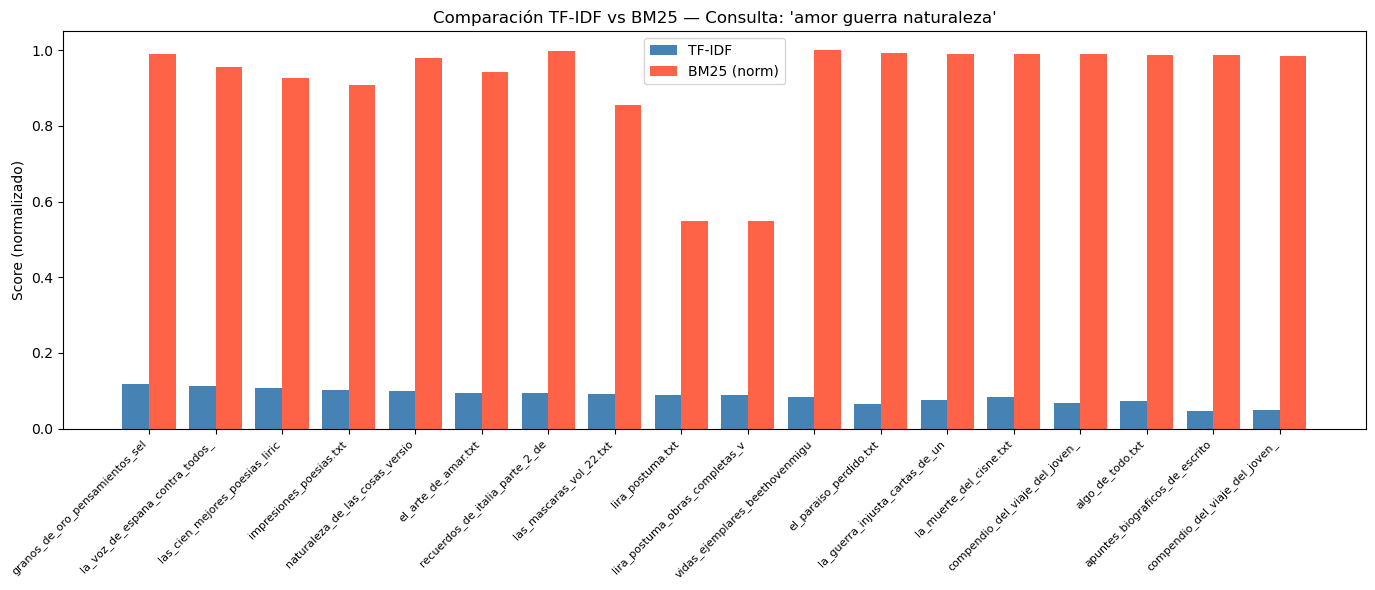

In [15]:
import matplotlib.pyplot as plt

# Top 10 de cada modelo
top_docs_tfidf = resultados['Documento'].tolist()
top_docs_bm25  = resultado_bm25['Documento'].tolist()

# Unión de los top docs de ambos modelos
todos = list(dict.fromkeys(top_docs_tfidf + top_docs_bm25))

# Scores TF-IDF para cada doc de la unión
scores_tfidf_all = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
tfidf_scores = [scores_tfidf_all[doc_names.index(d)] for d in todos]

# Scores BM25 para cada doc de la unión
query_vec   = count_vec.transform([query])
query_terms = query_vec.nonzero()[1]
scores_bm25_all = np.zeros(N)
for term_idx in query_terms:
    tf          = np.asarray(tf_matrix[:, term_idx].todense()).flatten()
    numerador   = tf * (k1 + 1)
    denominador = tf + k1 * (1 - b + b * doc_len / avgdl)
    scores_bm25_all += idf_bm25[term_idx] * (numerador / denominador)
bm25_scores = [scores_bm25_all[doc_names.index(d)] for d in todos]

# Normalizar BM25 a [0,1] para comparar en misma escala
bm25_scores_norm = np.array(bm25_scores) / max(bm25_scores)

# Gráfico de barras comparativo
x      = range(len(todos))
labels = [d[:30] for d in todos]  # truncar nombres largos

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - 0.2 for i in x], tfidf_scores,  width=0.4, label='TF-IDF',      color='steelblue')
ax.bar([i + 0.2 for i in x], bm25_scores_norm, width=0.4, label='BM25 (norm)', color='tomato')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Score (normalizado)')
ax.set_title(f"Comparación TF-IDF vs BM25 — Consulta: '{query}'")
ax.legend()
plt.tight_layout()
plt.show()
